## Librerias y semilla 

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, lognorm, expon, norm 
from scipy.optimize import brentq
import math
import pandas as pd 
np.random.seed(12345)

# Ejercicio 1 

En este problema tenemos una red de procesos industriales con tiempos aleatorios:

- $T_1 \sim \text{Exp}(\lambda=1)$
- $T_2 \sim \Gamma(\alpha=2,\beta=3)$
- $T_3 \sim \text{Exp}(\lambda=1.25)$
- $T_4 \sim \text{LogNormal}(\mu=0.2,\sigma^2=0.5)$
- $T_5 \sim \text{Exp}(\lambda=0.75)$

Nuestro objetivo es estimar el cuantil $p=0.95$ del tiempo total de entrega $T$, es decir, encontrar $q_{0.95}$ tal que:

$$
\mathbb{P}(T \le q_{0.95}) = 0.95.
$$

Además, vamos a hacerlo de tres maneras:

1. Monte Carlo vanilla
2. Monte Carlo condicionado
3. Monte Carlo con variable de control

## Construcción del tiempo total de entrega

De acuerdo con la red de procesos:

- El nodo $P_2$ empieza después de $T_1$.
- El nodo $P_3$ puede empezar:
  - directamente desde $P_1$, tardando $T_4$, o
  - pasando por $P_2$, tardando $T_1 + T_3$

Por lo tanto, el tiempo de inicio de $P_3$ es:

$$
\max(T_4, T_1 + T_3).
$$

Finalmente, la entrega en $E$ puede llegar:

- desde $P_2: T_1 + T_2$,
- desde $P_3: \max(T_4, T_1 + T_3) + T_5$.

Entonces el tiempo total de entrega es:

$$
T = \max\left(T_1 + T_2,\; \max(T_4, T_1 + T_3) + T_5\right).
$$

Equivalentemente:

$$
T = \max(T_1 + T_2,\; T_4 + T_5,\; T_1 + T_3 + T_5).
$$

Esta forma es mejor para la simulación.


## Parámetros de las distribuciones

Vamos a usar la siguiente parametrización:

- Si $X \sim \text{Exp}(\lambda)$, entonces en Python:
  ```python
  np.random.exponential(scale=1/lambda)
  ```

-  Si $X \sim \Gamma(\lambda, \beta)$, con $\beta$ escala , entonces: 
  ```python
  np.random.gamma(shape=alpha, scale=beta)
  ```

- Si $X \sim \text{LogNormal}(\mu, \sigma^2)$, entonces en Python:
  ```python
  np.random.lognormal(mean=mu, sigma=sigma)
  ```
donde $\sigma = \sqrt{\sigma^2}$


In [2]:
# Parámetros
lambda1 = 1.0
alpha2 = 2.0
beta2 = 3.0      # escala
lambda3 = 1.25
mu4 = 0.2
var4 = 0.5
sigma4 = np.sqrt(var4)
lambda5 = 0.75

## Funciones para simular las variables aleatorias

Vamos a crear funciones que generen muestras de cada variable y otra función que construya el tiempo total $T$.

In [3]:
def sample_T1(n):
    return np.random.exponential(scale=1/lambda1, size=n)

def sample_T2(n):
    return np.random.gamma(shape=alpha2, scale=beta2, size=n)

def sample_T3(n):
    return np.random.exponential(scale=1/lambda3, size=n)

def sample_T4(n):
    return np.random.lognormal(mean=mu4, sigma=sigma4, size=n)

def sample_T5(n):
    return np.random.exponential(scale=1/lambda5, size=n)

def build_total_time(t1, t2, t3, t4, t5):
    return np.maximum.reduce([
        t1 + t2,
        t4 + t5,
        t1 + t3 + t5
    ])

## Monte Carlo vanilla

1. Simular muchas veces $T_1,\dots,T_5$
2. Construir el tiempo total $T$
3. Calcular el percentil 95 empírico de la muestra simulada

Si tenemos $T^{(1)},\dots,T^{(n)}$, entonces estimamos:

$$
\hat q_{0.95} = \text{percentil 95 de } \{T^{(1)},\dots,T^{(n)}\}.
$$

In [4]:
def mc_vanilla(n):
    t1 = sample_T1(n)
    t2 = sample_T2(n)
    t3 = sample_T3(n)
    t4 = sample_T4(n)
    t5 = sample_T5(n)
    
    T = build_total_time(t1, t2, t3, t4, t5)
    q95 = np.quantile(T, 0.95)
    
    return {
        "T": T,
        "q95": q95
    }

In [5]:
n = 100_000
res_vanilla = mc_vanilla(n)

print("Cuantil 0.95 estimado por Monte Carlo vanilla:")
print(res_vanilla["q95"])

Cuantil 0.95 estimado por Monte Carlo vanilla:
15.476826493661193


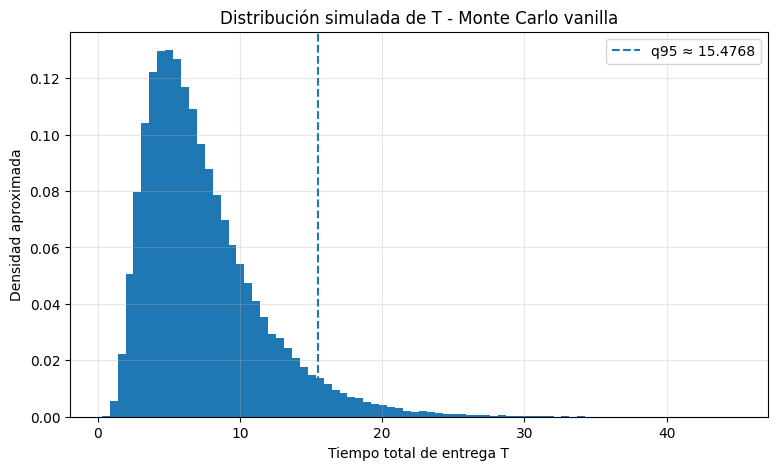

In [6]:
T_vanilla = res_vanilla["T"]
q95_vanilla = res_vanilla["q95"]

plt.figure(figsize=(9, 5))
plt.hist(T_vanilla, bins=80, density=True)
plt.axvline(q95_vanilla, linestyle='--', label=f'q95 ≈ {q95_vanilla:.4f}')
plt.xlabel("Tiempo total de entrega T")
plt.ylabel("Densidad aproximada")
plt.title("Distribución simulada de T - Monte Carlo vanilla")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Para estimar un intervalo de confianza del cuantil, una estrategia práctica es usar bootstrap:

1. Tomamos la muestra simulada $T^{(1)},\dots,T^{(n)}$
2. Re-muestreamos con reemplazo muchas veces
3. En cada remuestreo calculamos el cuantil 0.95
4. Tomamos percentiles de esos cuantiles bootstrap

Esto nos da un intervalo de confianza empírico para el cuantil.

In [7]:
def bootstrap_ci_quantile(sample, p=0.95, B=300, seed=123):
    rng = np.random.default_rng(seed)
    n = len(sample)
    qs = np.empty(B)
    
    for b in range(B):
        idx = rng.integers(0, n, size=n)
        boot_sample = sample[idx]
        qs[b] = np.quantile(boot_sample, p)
    
    ci_low, ci_high = np.quantile(qs, [0.025, 0.975])
    return {
        "bootstrap_quantiles": qs,
        "ci_low": ci_low,
        "ci_high": ci_high
    }

In [8]:
boot_vanilla = bootstrap_ci_quantile(T_vanilla, p=0.95, B=300, seed=123)

print("IC bootstrap al 95% para q0.95 (vanilla):")
print(f"[{boot_vanilla['ci_low']:.4f}, {boot_vanilla['ci_high']:.4f}]")

IC bootstrap al 95% para q0.95 (vanilla):
[15.3716, 15.5713]


## Monte Carlo condicionado

La idea del método condicionado es aprovechar parte de la estructura del problema para reducir la varianza.

Recordando que:

$$
T = \max(T_1+T_2,\; T_4+T_5,\; T_1+T_3+T_5).
$$

Queremos estimar la función de distribución:

$$
F_T(x)=\mathbb{P}(T\le x).
$$

Si condicionamos en $T_1=t_1, T_3=t_3, T_5=t_5$, entonces:

$$
T \le x
$$

equivale a que se cumplan simultáneamente:

$$
t_1 + T_2 \le x,
\qquad
T_4 + t_5 \le x,
\qquad
t_1 + t_3 + t_5 \le x.
$$

La tercera condición ya es determinista, así que:

$$
\mathbb{P}(T \le x \mid t_1,t_3,t_5) = \mathbf{1}_{\{t_1+t_3+t_5 \le x\}} F_{T_2}(x-t_1)\, F_{T_4}(x-t_5)
$$


Por ley de esperanza iterada:

$$
F_T(x)=\mathbb{E}\left[
\mathbf{1}_{\{T_1+T_3+T_5\le x\}}
F_{T_2}(x-T_1)\,
F_{T_4}(x-T_5)
\right].
$$

Esto nos permite estimar la CDF de forma más estable que con un simple indicador

In [9]:
def F_T2(x):
    # CDF de Gamma(alpha=2, beta=3)
    # beta como escala
    x = np.asarray(x)
    out = gamma.cdf(x, a=alpha2, scale=beta2)
    out = np.where(x < 0, 0.0, out)
    return out

def F_T4(x):
    # CDF de LogNormal(mu=0.2, sigma^2=0.5)
    x = np.asarray(x)
    out = lognorm.cdf(x, s=sigma4, scale=np.exp(mu4))
    out = np.where(x < 0, 0.0, out)
    return out

Definimos, para cada simulación:

$$
Y_i(x)=
\mathbf{1}_{\{T_1^{(i)}+T_3^{(i)}+T_5^{(i)}\le x\}}
F_{T_2}(x-T_1^{(i)})
F_{T_4}(x-T_5^{(i)}).
$$

Entonces:

$$
\hat F_n^{cond}(x)=\frac{1}{n}\sum_{i=1}^n Y_i(x).
$$

Después encontraremos el cuantil 0.95 resolviendo:

$$
\hat F_n^{cond}(x)=0.95.
$$

In [10]:
def conditional_cdf_estimator(x, t1, t3, t5):
    indicator = (t1 + t3 + t5 <= x).astype(float)
    return np.mean(indicator * F_T2(x - t1) * F_T4(x - t5))

def conditional_cdf_sample_values(x, t1, t3, t5):
    indicator = (t1 + t3 + t5 <= x).astype(float)
    return indicator * F_T2(x - t1) * F_T4(x - t5)

Como el cuantil satisface $F_T(q_{0.95})=0.95$, podemos buscarlo numéricamente.

Para eso vamos a:

1. simular una muestra de $T_1,T_3,T_5$,
2. definir la función $x \mapsto \hat F_n^{cond}(x)-0.95$,
3. encontrar su raíz.

In [11]:
def estimate_q95_conditional(n, x_low=0.0, x_high=40.0, seed=12345):
    rng = np.random.default_rng(seed)
    
    t1 = rng.exponential(scale=1/lambda1, size=n)
    t3 = rng.exponential(scale=1/lambda3, size=n)
    t5 = rng.exponential(scale=1/lambda5, size=n)
    
    def objective(x):
        return conditional_cdf_estimator(x, t1, t3, t5) - 0.95
    
    q95 = brentq(objective, x_low, x_high)
    
    return {
        "q95": q95,
        "t1": t1,
        "t3": t3,
        "t5": t5
    }

In [12]:
res_cond = estimate_q95_conditional(n=100_000, x_low=0.0, x_high=40.0, seed=12345)

print("Cuantil 0.95 estimado por Monte Carlo condicionado:")
print(res_cond["q95"])

Cuantil 0.95 estimado por Monte Carlo condicionado:
15.416135171086115


Para un valor fijo $x$, el estimador condicionado es el promedio de variables $Y_i(x)$, así que podemos usar:

$$
\hat F_n^{cond}(x) \pm 1.96 \frac{s_Y}{\sqrt{n}},
$$

donde $s_Y$ es la desviación estándar muestral de los $Y_i(x)$.

Vamos a calcular esto en el punto $x=\hat q_{0.95}^{cond}$

In [13]:
q95_cond = res_cond["q95"]
t1_cond = res_cond["t1"]
t3_cond = res_cond["t3"]
t5_cond = res_cond["t5"]

Y_q = conditional_cdf_sample_values(q95_cond, t1_cond, t3_cond, t5_cond)
Fhat_q = np.mean(Y_q)
se_q = np.std(Y_q, ddof=1) / np.sqrt(len(Y_q))

ci_low_F = Fhat_q - 1.96 * se_q
ci_high_F = Fhat_q + 1.96 * se_q

print("Estimación de F_T(q95_cond):", Fhat_q)
print("IC 95% para F_T(q95_cond):")
print(f"[{ci_low_F:.6f}, {ci_high_F:.6f}]")

Estimación de F_T(q95_cond): 0.95
IC 95% para F_T(q95_cond):
[0.949868, 0.950132]


Como el estimador del cuantil depende de una raíz numérica, una forma práctica de obtener un IC es volver a usar bootstrap.

En este caso haremos bootstrap sobre las simulaciones de $T_1,T_3,T_5$.

In [14]:
def bootstrap_ci_conditional_quantile(t1, t3, t5, B=200, seed=123):
    rng = np.random.default_rng(seed)
    n = len(t1)
    qs = np.empty(B)
    
    for b in range(B):
        idx = rng.integers(0, n, size=n)
        t1_b = t1[idx]
        t3_b = t3[idx]
        t5_b = t5[idx]
        
        def objective(x):
            return conditional_cdf_estimator(x, t1_b, t3_b, t5_b) - 0.95
        
        qs[b] = brentq(objective, 0.0, 40.0)
    
    ci_low, ci_high = np.quantile(qs, [0.025, 0.975])
    return {
        "bootstrap_quantiles": qs,
        "ci_low": ci_low,
        "ci_high": ci_high
    }

In [15]:
boot_cond = bootstrap_ci_conditional_quantile(t1_cond, t3_cond, t5_cond, B=200, seed=123)

print("IC bootstrap al 95% para q0.95 (condicionado):")
print(f"[{boot_cond['ci_low']:.4f}, {boot_cond['ci_high']:.4f}]")

IC bootstrap al 95% para q0.95 (condicionado):
[15.4061, 15.4260]


## Variable de control

Ahora construiremos una variable de control:

$$
V = \mathbf{1}_{\{T_1+T_3+T_5 \le \xi\}},
$$

donde $\xi$ se elige para que:

$$
\mathbb{E}[V] = \mathbb{P}(T_1+T_3+T_5 \le \xi)=0.95.
$$

Es decir, $\xi$ es el cuantil 0.95 de:

$$
S=T_1+T_3+T_5.
$$

La razón por la que esta variable es útil es que el término $T_1+T_3+T_5$ aparece dentro del máximo que define $T$, por lo que $V$ estará correlacionada con el evento $\{T\le x\}$.

### Cálculo de $\xi$

Como $T_1,T_3,T_5$ son exponenciales independientes con tasas distintas, la suma

$$
S = T_1 + T_3 + T_5
$$

tiene una distribución hipoexponencial.

Su CDF es de la forma:

$$
F_S(x)=1-\sum_{i=1}^3 a_i e^{-\lambda_i x}.
$$

En lugar de escribir la expresión cerrada a mano, la calcularemos numéricamente con simulación o usando la fórmula analítica.

In [16]:
def F_S_hypoexp(x):
    # tasas: 1, 1.25, 0.75
    # fórmula cerrada obtenida para la suma de exponenciales independientes con tasas distintas
    return 1 + 15*np.exp(-x) - 6*np.exp(-1.25*x) - 10*np.exp(-0.75*x)

def find_xi():
    f = lambda x: F_S_hypoexp(x) - 0.95
    return brentq(f, 0.0, 30.0)

xi = find_xi()
print("Valor de xi tal que E[V]=0.95:")
print(xi)

Valor de xi tal que E[V]=0.95:
6.658631890407347


### Estimador con variable de control

Queremos estimar:

$$
F_T(x)=\mathbb{E}[I_x], \qquad I_x=\mathbf{1}_{\{T\le x\}}.
$$

El estimador con variable de control es:

$$
\hat F_n^{cv}(x)=
\frac{1}{n}\sum_{i=1}^n
\left[
I_x^{(i)} - c\left(V^{(i)}-0.95\right)
\right].
$$

Aquí:

- $I_x^{(i)}=\mathbf{1}_{\{T^{(i)}\le x\}}$
- $V^{(i)}=\mathbf{1}_{\{T_1^{(i)}+T_3^{(i)}+T_5^{(i)}\le \xi\}}$

El mejor valor teórico de $c$ es:

$$
c^*=\frac{\mathrm{Cov}(I_x,V)}{\mathrm{Var}(V)}.
$$

En la práctica lo estimamos con los datos simulados.

In [17]:
def control_variate_cdf_estimator(x, t1, t2, t3, t4, t5, xi):
    T = build_total_time(t1, t2, t3, t4, t5)
    I = (T <= x).astype(float)
    V = (t1 + t3 + t5 <= xi).astype(float)
    
    V_mean_known = 0.95
    var_V = np.var(V, ddof=1)
    
    if var_V == 0:
        c_hat = 0.0
    else:
        c_hat = np.cov(I, V, ddof=1)[0, 1] / var_V
    
    est = np.mean(I - c_hat * (V - V_mean_known))
    return est, c_hat, I, V

Ahora simulamos todas las variables, construimos el estimador de la CDF con variable de control y resolvemos numéricamente:

$$
\hat F_n^{cv}(x)=0.95.
$$

In [18]:
def estimate_q95_control_variate(n, xi, x_low=0.0, x_high=40.0, seed=12345):
    rng = np.random.default_rng(seed)
    
    t1 = rng.exponential(scale=1/lambda1, size=n)
    t2 = rng.gamma(shape=alpha2, scale=beta2, size=n)
    t3 = rng.exponential(scale=1/lambda3, size=n)
    t4 = rng.lognormal(mean=mu4, sigma=sigma4, size=n)
    t5 = rng.exponential(scale=1/lambda5, size=n)
    
    def objective(x):
        est, _, _, _ = control_variate_cdf_estimator(x, t1, t2, t3, t4, t5, xi)
        return est - 0.95
    
    q95 = brentq(objective, x_low, x_high)
    
    return {
        "q95": q95,
        "t1": t1,
        "t2": t2,
        "t3": t3,
        "t4": t4,
        "t5": t5
    }

In [19]:
res_cv = estimate_q95_control_variate(n=100_000, xi=xi, x_low=0.0, x_high=40.0, seed=12345)

print("Cuantil 0.95 estimado por Monte Carlo con variable de control:")
print(res_cv["q95"])

Cuantil 0.95 estimado por Monte Carlo con variable de control:
15.409356743395879


Para un valor fijo $x$, podemos construir la muestra:

$$
Z_i(x)=I_x^{(i)}-c(V^{(i)}-0.95),
$$

y entonces:

$$
\hat F_n^{cv}(x)=\frac{1}{n}\sum_{i=1}^n Z_i(x).
$$

Usamos el error estándar muestral de los $Z_i(x)$ para construir un intervalo de confianza.

In [20]:
q95_cv = res_cv["q95"]

est_cv_q, c_hat_q, I_q, V_q = control_variate_cdf_estimator(
    q95_cv,
    res_cv["t1"], res_cv["t2"], res_cv["t3"], res_cv["t4"], res_cv["t5"],
    xi
)

Z_q = I_q - c_hat_q * (V_q - 0.95)
se_cv_q = np.std(Z_q, ddof=1) / np.sqrt(len(Z_q))

ci_low_cv_F = est_cv_q - 1.96 * se_cv_q
ci_high_cv_F = est_cv_q + 1.96 * se_cv_q

print("Estimación de F_T(q95_cv):", est_cv_q)
print("c_hat en q95_cv:", c_hat_q)
print("IC 95% para F_T(q95_cv):")
print(f"[{ci_low_cv_F:.6f}, {ci_high_cv_F:.6f}]")

Estimación de F_T(q95_cv): 0.9499952206213051
c_hat en q95_cv: 0.03133277359863965
IC 95% para F_T(q95_cv):
[0.948645, 0.951345]


Volvemos a usar bootstrap, ahora sobre todas las variables simuladas.

In [21]:
def bootstrap_ci_control_variate_quantile(t1, t2, t3, t4, t5, xi, B=200, seed=123):
    rng = np.random.default_rng(seed)
    n = len(t1)
    qs = np.empty(B)
    
    for b in range(B):
        idx = rng.integers(0, n, size=n)
        t1_b = t1[idx]
        t2_b = t2[idx]
        t3_b = t3[idx]
        t4_b = t4[idx]
        t5_b = t5[idx]
        
        def objective(x):
            est, _, _, _ = control_variate_cdf_estimator(x, t1_b, t2_b, t3_b, t4_b, t5_b, xi)
            return est - 0.95
        
        qs[b] = brentq(objective, 0.0, 40.0)
    
    ci_low, ci_high = np.quantile(qs, [0.025, 0.975])
    return {
        "bootstrap_quantiles": qs,
        "ci_low": ci_low,
        "ci_high": ci_high
    }

In [22]:
boot_cv = bootstrap_ci_control_variate_quantile(
    res_cv["t1"], res_cv["t2"], res_cv["t3"], res_cv["t4"], res_cv["t5"],
    xi=xi, B=200, seed=123
)

print("IC bootstrap al 95% para q0.95 (variable de control):")
print(f"[{boot_cv['ci_low']:.4f}, {boot_cv['ci_high']:.4f}]")

IC bootstrap al 95% para q0.95 (variable de control):
[15.3080, 15.4965]


## Comparacion de resultados 

Ahora reunimos los resultados de los tres métodos:

- Monte Carlo vanilla
- Monte Carlo condicionado
- Monte Carlo con variable de control

Para comparar si todos estiman aproximadamente el mismo cuantil y qué tan estables son sus intervalos.

In [24]:
print("Resumen de resultados\n")

print("Monte Carlo vanilla")
print(f"q0.95 = {q95_vanilla:.4f}")
print(f"IC bootstrap 95% = [{boot_vanilla['ci_low']:.4f}, {boot_vanilla['ci_high']:.4f}]")
print()

print("Monte Carlo condicionado")
print(f"q0.95 = {q95_cond:.4f}")
print(f"IC bootstrap 95% = [{boot_cond['ci_low']:.4f}, {boot_cond['ci_high']:.4f}]")
print()

print("Monte Carlo con variable de control")
print(f"q0.95 = {q95_cv:.4f}")
print(f"IC bootstrap 95% = [{boot_cv['ci_low']:.4f}, {boot_cv['ci_high']:.4f}]")
print()

print(f"xi = {xi:.4f}")

Resumen de resultados

Monte Carlo vanilla
q0.95 = 15.4768
IC bootstrap 95% = [15.3716, 15.5713]

Monte Carlo condicionado
q0.95 = 15.4161
IC bootstrap 95% = [15.4061, 15.4260]

Monte Carlo con variable de control
q0.95 = 15.4094
IC bootstrap 95% = [15.3080, 15.4965]

xi = 6.6586


En este ejercicio se estimó el cuantil 0.95 del tiempo total de entrega $T$ usando tres enfoques de simulación Monte Carlo. Los tres métodos dieron resultados muy cercanos, alrededor de $15.4$, lo cual da confianza en que la estimación es consistente.

En particular, Monte Carlo vanilla dio $q_{0.95}=15.4768$, mientras que el método condicionado y el de variable de control dieron $15.4161$ y $15.4094$, respectivamente. Esto sugiere que, para este problema, una fecha de entrega cercana a 15.4 unidades de tiempo cubriría aproximadamente el 95\% de los casos.

Además, se observa que el método condicionado produjo el intervalo de confianza más estrecho, por lo que fue el más preciso de los tres. Esto tiene sentido, ya que aprovecha mejor la estructura del problema y reduce la variabilidad del estimador. Por su parte, el método con variable de control también mejoró la estimación, aunque en este caso no fue tan preciso como el condicionado.

En conclusión, los tres métodos funcionan correctamente, pero el Monte Carlo condicionado resultó ser la mejor alternativa para este problema, al ofrecer una estimación muy estable y con menor incertidumbre.

# Ejercicio 2 

Vamos a: 

- Demostrar propiedades teóricas de covarianza con funciones monótonas
- Implementar el método de variables antitéticas
- Comparar varianza vs Monte Carlo estándar 

## 2.1 Demostración: Cov(f(X), g(X)) ≥ 0

Sean f y g funciones no decrecientes y X una variable aleatoria.

Queremos probar:

$Cov(f(X), g(X)) ≥ 0$

**La idea es**

Para cualquier x, y:

$(f(x) - f(y))(g(x) - g(y)) ≥ 0$

porque ambas funciones crecen en el mismo sentido.


1. Tomamos X y Y independientes con la misma distribución
2. Usamos:

$E[(f(X)-f(Y))(g(X)-g(Y))] ≥ 0$

3. Expandimos:

$$
= E[f(X)g(X)] 
- E[f(X)g(Y)] 
- E[f(Y)g(X)] 
+ E[f(Y)g(Y)]
$$

4. Usamos independencia:

$E[f(X)g(Y)] = E[f(X)]E[g(Y)]$

5. Como X y Y tienen misma distribución:

$E[f(Y)] = E[f(X)]$

Entonces:

$2E[f(X)g(X)] - 2E[f(X)]E[g(X)] ≥ 0$

Dividiendo entre 2:

$Cov(f(X), g(X)) ≥ 0$

## 2.2 Variables Antitéticas

Sea $U \sim Uniforme(0,1)$

Entonces:

$X = F^{-1}(U)$

También:

$X' = F^{-1}(1 - U)$

Ambas tienen la misma distribución.

Si U es grande → 1-U es pequeño

Entonces:
- $F^{-1}(U)$ es grande
- $F^{-1}(1-U)$ es pequeño

Se mueven en sentido opuesto → covarianza negativa

$μ ≈ \frac{1}{(2n)} \sum [h(F^{-1}(U_i)) + h(F^{-1}(1-U_i))]$

Esto reduce la varianza.

**Ejemplo**

Tomamos:

$X \sim Exponencial(1)$

Entonces:

$F^{-1}(u) = -ln(1-u)$

Queremos estimar:

$E[X^2] = 2$

In [2]:
def F_inv_exp(u):
    return -np.log(1 - u)

def h(x):
    return x**2

## Monte Carlo Crudo 

In [3]:
def mc_crudo(n):
    U = np.random.rand(n)
    X = F_inv_exp(U)
    return np.mean(h(X))

## Monte Carlo Antitetico

In [4]:
def mc_antitetico(n):
    m = n // 2
    
    U = np.random.rand(m)
    X1 = F_inv_exp(U)
    X2 = F_inv_exp(1 - U)
    
    valores = list(h(X1))
    valores.extend(h(X2))
    
    if n % 2 == 1:
        u_extra = np.random.rand()
        valores.append(h(F_inv_exp(u_extra)))
    
    return np.mean(valores)

## Simulacion 

In [5]:
ns = range(2, 101)
R = 1000

var_crudo = []
var_ant = []

media_crudo = []
media_ant = []

for n in ns:
    crudo = np.array([mc_crudo(n) for _ in range(R)])
    ant = np.array([mc_antitetico(n) for _ in range(R)])
    
    var_crudo.append(np.var(crudo, ddof=1))
    var_ant.append(np.var(ant, ddof=1))
    
    media_crudo.append(np.mean(crudo))
    media_ant.append(np.mean(ant))

In [6]:
print("Valor real:", 2)

for n in [20, 50, 100]:
    i = n - 2
    print(f"\nn={n}")
    print("Media crudo:", media_crudo[i])
    print("Media antitético:", media_ant[i])
    print("Var crudo:", var_crudo[i])
    print("Var antitético:", var_ant[i])

Valor real: 2

n=20
Media crudo: 2.0436816692024506
Media antitético: 2.037418621191377
Var crudo: 0.9858758533721323
Var antitético: 0.9135078058702492

n=50
Media crudo: 1.9801975226246218
Media antitético: 2.0044649638256304
Var crudo: 0.3717857808494702
Var antitético: 0.317829116475488

n=100
Media crudo: 2.0236272450545543
Media antitético: 2.004965847902111
Var crudo: 0.19696585078977266
Var antitético: 0.1512863900206023


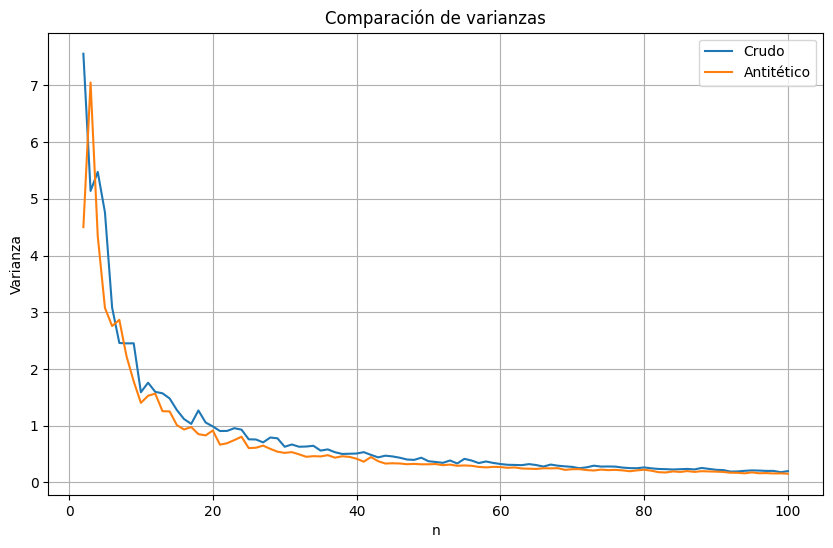

In [7]:
plt.figure(figsize=(10,6))
plt.plot(list(ns), var_crudo, label="Crudo")
plt.plot(list(ns), var_ant, label="Antitético")
plt.legend()
plt.xlabel("n")
plt.ylabel("Varianza")
plt.title("Comparación de varianzas")
plt.grid()
plt.show()

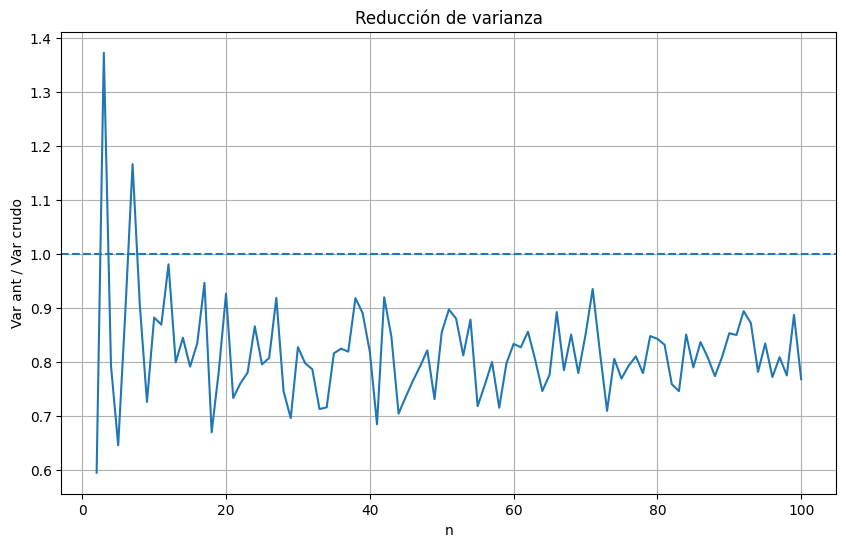

In [8]:
razon = np.array(var_ant) / np.array(var_crudo)

plt.figure(figsize=(10,6))
plt.plot(list(ns), razon)
plt.axhline(1, linestyle="--")
plt.xlabel("n")
plt.ylabel("Var ant / Var crudo")
plt.title("Reducción de varianza")
plt.grid()
plt.show()

Primero vemos, ambos métodos (crudo y antitético) producen estimaciones cercanas al valor real de $ \mathbb{E}[X^2] = 2 $. Esto confirma que ambos estimadores son **insesgados**, es decir, en promedio convergen al valor verdadero.

Sin embargo, la diferencia clave aparece en la **varianza de los estimadores**:

- Para $ n = 20 $, la varianza se reduce de **0.986 → 0.914**
- Para $ n = 50 $, de **0.372 → 0.318**
- Para $ n = 100 $, de **0.197 → 0.151**

Esto muestra consistentemente que el método antitético produce estimaciones **más estables**, es decir, con menor dispersión.

ESe mejora ya que el método antitético introduce una **dependencia negativa** entre las observaciones:

- Si una simulación produce un valor alto, su pareja tiende a producir un valor bajo
- Esto genera una especie de "balance" en el promedio
- Por lo tanto se diminiye la desviacion del estimador 

# Ejercicio 3 

Aqui es esta estimando la integral de : 

$$
I=\int_{[0,1]^2} h(x,y)\,dx\,dy
$$

utilizando:

- Monte Carlo crudo
- Monte Carlo estratificado

Se usarán:

- 500 simulaciones por experimento
- 1000 repeticiones
- Estratos $ S \in \{2,4,8,16\} $

Se calcularán:

- Estimadores de la integral
- Intervalos de confianza al 95%
- Cobertura de los intervalos
- Varianza empírica de los estimadores

## Función elegida

Se elige:

$$
h(x,y)=e^{x+y}
$$

La integral exacta es:

$$
I=(e-1)^2
$$

In [39]:
def h(x, y):
    return np.exp(x + y)

I_real = (math.e - 1)**2
print("Valor real de la integral:", I_real)

Valor real de la integral: 2.9524924420125593


## Monte Carlo Crudo

El estimador es:

$$
\hat I = \frac{1}{n}\sum_{i=1}^n h(X_i,Y_i)
$$

donde $(X_i,Y_i)\sim U([0,1]^2)$

In [40]:
def mc_crudo_una_vez(n=500, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    
    x = rng.random(n)
    y = rng.random(n)
    
    valores = h(x, y)
    estimador = np.mean(valores)
    
    s2 = np.var(valores, ddof=1)
    se = np.sqrt(s2 / n)
    
    li = estimador - 1.96 * se
    ls = estimador + 1.96 * se
    
    cubre = (li <= I_real <= ls)
    
    return estimador, s2/n, cubre

## Monte Carlo Estratificado

Se divide el cuadrado en una malla $ S \times S $, generando:

$$
H = S^2
$$

estratos.

El estimador es:

$$
\hat I = \sum_{h=1}^H w_h \bar{Z}_h
$$

donde:

- $ w_h = 1/H $
- $ \bar{Z}_h $ es el promedio en el estrato $ h $

In [41]:
def repartir_muestras(n, H):
    base = n // H
    resto = n % H
    nh = np.full(H, base, dtype=int)
    nh[:resto] += 1
    return nh

def mc_estratificado_una_vez(S=2, n=500, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    
    H = S * S
    pesos = np.full(H, 1/H)
    nh = repartir_muestras(n, H)
    
    medias = []
    vars_ = []
    
    idx = 0
    for i in range(S):
        for j in range(S):
            m = nh[idx]
            
            u = rng.random(m)
            v = rng.random(m)
            
            x = (i + u) / S
            y = (j + v) / S
            
            vals = h(x, y)
            
            media = np.mean(vals)
            var = np.var(vals, ddof=1) if m > 1 else 0
            
            medias.append(media)
            vars_.append(var)
            
            idx += 1
    
    medias = np.array(medias)
    vars_ = np.array(vars_)
    
    estimador = np.sum(pesos * medias)
    var_est = np.sum((pesos**2) * (vars_ / nh))
    
    se = np.sqrt(var_est)
    
    li = estimador - 1.96 * se
    ls = estimador + 1.96 * se
    
    cubre = (li <= I_real <= ls)
    
    return estimador, var_est, cubre

Se repite cada método 1000 veces para estimar:

- Varianza empírica
- Cobertura del intervalo

In [42]:
def experimento(metodo="crudo", S=None, n=500, R=1000, seed=123):
    rng = np.random.default_rng(seed)
    
    estimadores = []
    coberturas = []
    
    for _ in range(R):
        if metodo == "crudo":
            est, var_est, cubre = mc_crudo_una_vez(n, rng)
        else:
            est, var_est, cubre = mc_estratificado_una_vez(S, n, rng)
        
        estimadores.append(est)
        coberturas.append(cubre)
    
    estimadores = np.array(estimadores)
    coberturas = np.array(coberturas)
    
    return {
        "metodo": metodo,
        "S": S,
        "media": np.mean(estimadores),
        "var_empirica": np.var(estimadores, ddof=1),
        "cobertura": np.mean(coberturas) * 100
    }

## Resultados 

In [44]:
resultados = []

# Crudo
resultados.append(experimento("crudo"))

# Estratificado
for S in [2, 4, 8, 16]:
    resultados.append(experimento("estratificado", S=S))

df = pd.DataFrame(resultados)
df

,metodo,S,media,var_empirica,cobertura
0,crudo,NaN,2.951313,0.003064,94.7
1,estratificado,2.0,2.952166,0.000870,95.0
2,estratificado,4.0,2.952510,0.000226,94.3
3,estratificado,8.0,2.952498,0.000058,94.7
4,estratificado,16.0,2.952439,0.000015,90.5


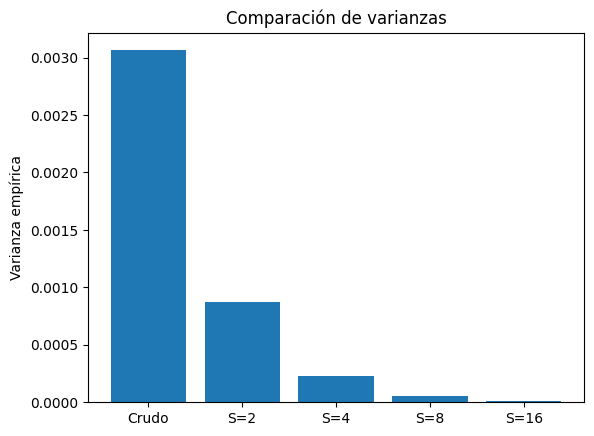

In [45]:
labels = []
vars_emp = []

for _, row in df.iterrows():
    if row["metodo"] == "crudo":
        labels.append("Crudo")
    else:
        labels.append(f"S={int(row['S'])}")
    vars_emp.append(row["var_empirica"])

plt.figure()
plt.bar(labels, vars_emp)
plt.ylabel("Varianza empírica")
plt.title("Comparación de varianzas")
plt.show()

Los resultados muestran que ambos métodos estiman correctamente la integral, ya que todas las medias están muy cercanas al valor real. Sin embargo, el Monte Carlo estratificado reduce de forma significativa la varianza respecto al método crudo, y esta mejora se vuelve más evidente conforme aumenta el número de estratos.

En particular, se observa que pasar de 
$S=2$ a $S=16$ disminuye drásticamente la variabilidad del estimador, lo que implica estimaciones más estables y precisas. No obstante, cuando el número de estratos es muy grande (como $S=16$), la cobertura del intervalo de confianza disminuye, probablemente porque hay muy pocas muestras dentro de cada estrato, lo que afecta la estimación de la varianza.

El muestreo estratificado es claramente más eficiente que el Monte Carlo crudo, pero existe un balance importante entre número de estratos y número de muestras por estrato para mantener buenas propiedades estadísticas.

# Ejercicio 4 

En este ejercicio se desea valuar una opción asiática call cuyo subyacente sigue aproximadamente un proceso de **Cox-Ingersoll-Ross (CIR)**, simulando trayectorias mediante el esquema de **Euler-Maruyama**.

La opción a valuar es:

$$
V = \mathbb{E}\left[e^{-rT}\max\left(0,\left(\frac{1}{n}\sum_{i=1}^n S_i\right)-K\right)\right]
$$

donde el proceso se aproxima mediante:

$$
S_i = S_{i-1} + \theta(\mu - S_{i-1})\Delta + \sigma \sqrt{\Delta S_{i-1}} Z_i
$$

con:

- $Z_i \sim N(0,1)$ i.i.d.
- $S_0 = 5$
- $\Delta = 0.01$
- $n = 5000$
- $\mu = 4$
- $\theta = 0.15$
- $\sigma = 0.2$
- $r = 0.05$
- $K = 3.5$

Además, el horizonte total es:

$$
T = n\Delta = 5000(0.01)=50
$$

Se resolverá usando:

1. **Monte Carlo vainilla**
2. **Monte Carlo con variables antitéticas**

Idea del proceso CIR

El proceso discretizado es:

$$
S_i = S_{i-1} + \theta(\mu - S_{i-1})\Delta + \sigma \sqrt{\Delta S_{i-1}} Z_i
$$

Este modelo tiene tres partes:

1. Componente actual
$$
S_{i-1}
$$

Es el valor del proceso en el paso anterior.

2. Término de reversión a la media
$$
\theta(\mu - S_{i-1})\Delta
$$

Este término hace que el proceso tienda a regresar a su nivel medio de largo plazo $\mu$.

- Si $S_{i-1}<\mu$, entonces el término es positivo y empuja el proceso hacia arriba.
- Si $S_{i-1}>\mu$, entonces el término es negativo y empuja el proceso hacia abajo.

3. Término aleatorio
$$
\sigma \sqrt{\Delta S_{i-1}}Z_i
$$

Introduce incertidumbre o ruido aleatorio.  
La volatilidad depende de $\sqrt{S_{i-1}}$, por lo que cuando el proceso es pequeño, también lo es su variabilidad.

La opción depende del promedio aritmético de la trayectoria simulada:

$$
A = \frac{1}{n}\sum_{i=1}^n S_i
$$

El payoff al vencimiento es:

$$
\max(0, A-K)
$$

Como se requiere el valor presente, se descuenta con la tasa libre de riesgo:

$$
e^{-rT}\max(0,A-K)
$$

Por tanto, el precio de la opción es la esperanza de este payoff descontado.

**Observación importante sobre la simulación**

Aunque el proceso CIR continuo es no negativo bajo ciertas condiciones, el esquema de Euler-Maruyama puede producir valores negativos por error de discretización.

Esto es importante porque en la simulación aparece:

$$
\sqrt{S_{i-1}}
$$

y no se puede calcular la raíz cuadrada de un número negativo en los reales.

Por ello, en la implementación usaremos una corrección práctica:

$$
\sqrt{\max(S_{i-1},0)}
$$

y además truncaremos:

$$
S_i = \max(S_i,0)
$$

Esto ayuda a mantener la simulación numéricamente estable.

In [25]:
# Parámetros del problema
S0 = 5
Delta = 0.01
n = 5000
mu = 4
theta = 0.15
sigma = 0.2
r = 0.05
K = 3.5

# Horizonte total
T = n * Delta

print("Horizonte T =", T)

Horizonte T = 50.0


## Función para simular una trayectoria del proceso CIR

Ahora construimos una función que reciba un vector de normales estándar $Z_1,\dots,Z_n$ y genere una trayectoria:

$$
S_1,S_2,\dots,S_n
$$

usando Euler-Maruyama.

In [26]:
def simular_cir_euler(S0, Delta, n, mu, theta, sigma, Z):
    """
    Simula una trayectoria de un proceso CIR con Euler-Maruyama.
    
    Parámetros:
    -----------
    S0 : float
        Valor inicial.
    Delta : float
        Paso de tiempo.
    n : int
        Número de pasos.
    mu : float
        Media de largo plazo.
    theta : float
        Velocidad de reversión a la media.
    sigma : float
        Volatilidad.
    Z : np.ndarray
        Vector de normales estándar de longitud n.
    
    Regresa:
    --------
    np.ndarray
        Trayectoria simulada S1,...,Sn
    """
    S = np.zeros(n + 1)
    S[0] = S0
    
    for i in range(1, n + 1):
        S_prev = max(S[i - 1], 0)  # evita raíz de número negativo
        
        S[i] = (
            S[i - 1]
            + theta * (mu - S[i - 1]) * Delta
            + sigma * np.sqrt(Delta * S_prev) * Z[i - 1]
        )
        
        # truncación para mantener no negatividad
        S[i] = max(S[i], 0)
    
    return S[1:]

## Simulación de una trayectoria de ejemplo

Antes de hacer Monte Carlo, conviene visualizar una sola trayectoria para entender el comportamiento del proceso.

In [27]:
Z = np.random.normal(0, 1, n)
trayectoria = simular_cir_euler(S0, Delta, n, mu, theta, sigma, Z)

print("Primeros 10 valores simulados:")
print(trayectoria[:10])

Primeros 10 valores simulados:
[4.97956467 5.02917688 4.98444961 4.99359383 5.06814474 5.03103969
 5.09044917 5.0375062  5.11958797 5.16348882]


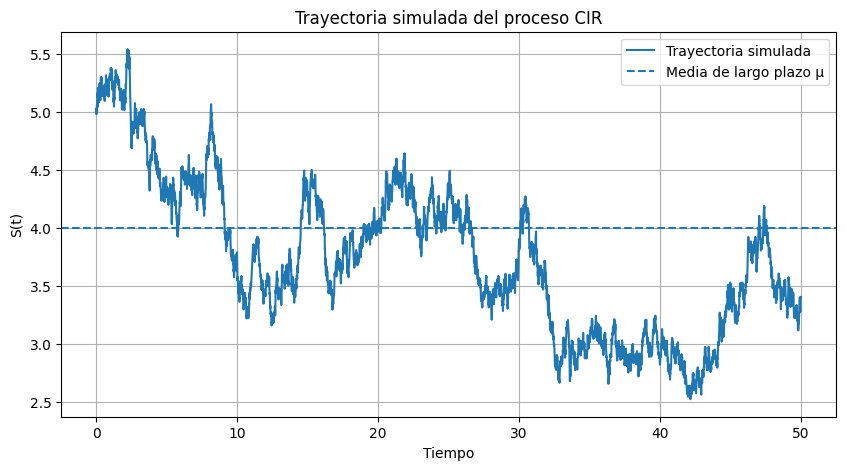

In [28]:
tiempos = np.linspace(Delta, T, n)

plt.figure(figsize=(10,5))
plt.plot(tiempos, trayectoria, label="Trayectoria simulada")
plt.axhline(mu, linestyle='--', label='Media de largo plazo μ')
plt.title("Trayectoria simulada del proceso CIR")
plt.xlabel("Tiempo")
plt.ylabel("S(t)")
plt.legend()
plt.grid(True)
plt.show()

## Función para calcular el payoff descontado


Para una trayectoria simulada, primero calculamos el promedio:

$$
A = \frac{1}{n}\sum_{i=1}^n S_i
$$

y luego el payoff descontado:

$$
e^{-rT}\max(0,A-K)
$$

In [29]:
def payoff_asiatico_descuento(trayectoria, r, T, K):
    """
    Calcula el payoff descontado de una opción asiática call.
    """
    promedio = np.mean(trayectoria)
    payoff = np.exp(-r * T) * max(0, promedio - K)
    return payoff

In [30]:
payoff_ejemplo = payoff_asiatico_descuento(trayectoria, r, T, K)
print("Payoff descontado de la trayectoria de ejemplo:", payoff_ejemplo)

Payoff descontado de la trayectoria de ejemplo: 0.019368069933677998


## Monte Carlo vainilla

En Monte Carlo vainilla se repite el siguiente procedimiento muchas veces:

1. Simular una trayectoria del proceso.
2. Calcular el payoff descontado.
3. Guardar ese payoff.
4. Promediar todos los payoffs.

Si usamos $M$ simulaciones, el estimador es:

$$
\hat{V}_{MC} = \frac{1}{M}\sum_{j=1}^{M} X^{(j)}
$$

donde $X^{(j)}$ es el payoff descontado de la simulación $j$.

In [31]:
def monte_carlo_vainilla(M, S0, Delta, n, mu, theta, sigma, r, K, semilla=None):
    """
    Estima el precio de la opción asiática mediante Monte Carlo vainilla.
    """
    if semilla is not None:
        np.random.seed(semilla)
    
    payoffs = np.zeros(M)
    
    for j in range(M):
        Z = np.random.normal(0, 1, n)
        trayectoria = simular_cir_euler(S0, Delta, n, mu, theta, sigma, Z)
        payoffs[j] = payoff_asiatico_descuento(trayectoria, r, n * Delta, K)
    
    precio = np.mean(payoffs)
    error_std = np.std(payoffs, ddof=1) / np.sqrt(M)
    ic_95 = (precio - 1.96 * error_std, precio + 1.96 * error_std)
    
    return precio, error_std, ic_95, payoffs

In [32]:
M = 10000

precio_mc, se_mc, ic_mc, payoffs_mc = monte_carlo_vainilla(
    M=M,
    S0=S0,
    Delta=Delta,
    n=n,
    mu=mu,
    theta=theta,
    sigma=sigma,
    r=r,
    K=K,
    semilla=123
)

print("Monte Carlo vainilla")
print("Precio estimado :", precio_mc)
print("Error estándar  :", se_mc)
print("IC 95%          :", ic_mc)

Monte Carlo vainilla
Precio estimado : 0.052560691269085615
Error estándar  : 0.00028082860537970454
IC 95%          : (np.float64(0.05201026720254139), np.float64(0.05311111533562984))


## Monte Carlo con variables antitéticas

La técnica antitética busca reducir la varianza del estimador.

En lugar de usar solo un vector de normales:

$$
Z=(Z_1,\dots,Z_n)
$$

también se usa su opuesto:

$$
-Z=(-Z_1,\dots,-Z_n)
$$

Con ello se generan dos trayectorias:

- una usando $Z$
- otra usando $-Z$

Se calculan dos payoffs y luego se promedian:

$$
Y = \frac{X(Z) + X(-Z)}{2}
$$

Finalmente, el estimador antitético es:

$$
\hat{V}_{anti} = \frac{1}{M}\sum_{j=1}^{M} Y^{(j)}
$$

Este método mantiene el mismo valor esperado, pero normalmente reduce la varianza.

In [33]:
def monte_carlo_antitetico(M, S0, Delta, n, mu, theta, sigma, r, K, semilla=None):
    """
    Estima el precio de la opción asiática mediante variables antitéticas.
    """
    if semilla is not None:
        np.random.seed(semilla)
    
    estimadores = np.zeros(M)
    
    for j in range(M):
        Z = np.random.normal(0, 1, n)
        
        # Trayectoria con Z
        trayectoria_pos = simular_cir_euler(S0, Delta, n, mu, theta, sigma, Z)
        payoff_pos = payoff_asiatico_descuento(trayectoria_pos, r, n * Delta, K)
        
        # Trayectoria con -Z
        trayectoria_neg = simular_cir_euler(S0, Delta, n, mu, theta, sigma, -Z)
        payoff_neg = payoff_asiatico_descuento(trayectoria_neg, r, n * Delta, K)
        
        # Promedio antitético
        estimadores[j] = 0.5 * (payoff_pos + payoff_neg)
    
    precio = np.mean(estimadores)
    error_std = np.std(estimadores, ddof=1) / np.sqrt(M)
    ic_95 = (precio - 1.96 * error_std, precio + 1.96 * error_std)
    
    return precio, error_std, ic_95, estimadores

In [34]:
precio_anti, se_anti, ic_anti, estimadores_anti = monte_carlo_antitetico(
    M=M,
    S0=S0,
    Delta=Delta,
    n=n,
    mu=mu,
    theta=theta,
    sigma=sigma,
    r=r,
    K=K,
    semilla=123
)

print("Monte Carlo antitético")
print("Precio estimado :", precio_anti)
print("Error estándar  :", se_anti)
print("IC 95%          :", ic_anti)

Monte Carlo antitético
Precio estimado : 0.05219867357397227
Error estándar  : 3.2624248019761865e-05
IC 95%          : (np.float64(0.05213473004785353), np.float64(0.052262617100091))


## Comparación de resultados

Ahora comparamos ambos métodos.

Lo esperado es:

- precios estimados parecidos
- menor error estándar en el método antitético
- por tanto, menor varianza del estimador

In [35]:
print(f"{'Método':<25}{'Precio':<15}{'Error estándar':<15}")
print("-" * 50)
print(f"{'Vainilla':<25}{precio_mc:<15.8f}{se_mc:<15.8f}")
print(f"{'Antitético':<25}{precio_anti:<15.8f}{se_anti:<15.8f}")

Método                   Precio         Error estándar 
--------------------------------------------------
Vainilla                 0.05256069     0.00028083     
Antitético               0.05219867     0.00003262     


In [36]:
reduccion = 1 - (se_anti**2 / se_mc**2)
print("Reducción aproximada de varianza:", reduccion)

Reducción aproximada de varianza: 0.9865042093194405


Con el método de **Monte Carlo vainilla** se obtuvo un precio estimado de:

$$
\hat V_{MC} = 0.05256069
$$

con un error estándar de:

$$
SE_{MC} = 0.00028083
$$

Por otro lado, utilizando el método de **variables antitéticas**, se obtuvo:

$$
\hat V_{anti} = 0.05219867
$$

con un error estándar significativamente menor:

$$
SE_{anti} = 0.00003262
$$

En primer lugar, se observa que **ambos métodos producen estimaciones muy cercanas del precio de la opción**, lo cual es consistente con la teoría, ya que ambos estimadores son insesgados y aproximan la misma esperanza matemática.

La ligera diferencia entre los valores estimados se debe a la variabilidad inherente al método Monte Carlo, la cual depende del número de simulaciones realizadas.

Sin embargo, la diferencia más importante radica en el **error estándar**. El método antitético presenta una reducción muy significativa en la dispersión del estimador. Esto se confirma con la reducción aproximada de varianza:

$$
\text{Reducción de varianza} \approx 98.65\%
$$

Esto implica que el estimador antitético es mucho más eficiente, ya que logra una precisión considerablemente mayor con el mismo número de simulaciones.

Esta mejora se debe a que las trayectorias generadas con $Z$ y $-Z$ tienden a compensarse, reduciendo la variabilidad del estimador final.

En este ejercicio se simuló un proceso CIR mediante el esquema de Euler-Maruyama para valuar una opción asiática call usando técnicas de Monte Carlo.

Se implementaron dos métodos: **Monte Carlo vainilla** y **Monte Carlo con variables antitéticas**. Ambos produjeron estimaciones consistentes del precio de la opción, lo que valida la correcta implementación de los algoritmos.

No obstante, el método antitético mostró una **reducción drástica en la varianza del estimador (≈ 98.65%)**, reflejada en un error estándar mucho menor en comparación con el método vainilla.

Esto demuestra que el uso de variables antitéticas es una técnica altamente efectiva para mejorar la eficiencia de simulaciones Monte Carlo, permitiendo obtener resultados más precisos sin necesidad de aumentar el número de simulaciones.

En conclusión, aunque ambos métodos son válidos, el método antitético resulta claramente superior en términos de precisión y eficiencia computacional para este problema.

# Ejercicio 5 

Nos piden dos cosas:

**Inciso 5.1**
Mostrar que si $X_1,\dots,X_n \overset{iid}{\sim} g$, entonces

$$
\frac{1}{n}\sum_{i=1}^n X_i \frac{f(X_i)}{g(X_i)}
$$

es una aproximación Monte Carlo apropiada de

$$
\mathbb{E}_{X\sim \mathcal{L}(f)}[X]
$$

**Inciso 5.2**
De manera similar, proponer un estimador Monte Carlo para

$$
\mathbb{E}_{X\sim \mathcal{L}(f)}[h(X)]
$$

cuando $X_1,\dots,X_n \overset{iid}{\sim} g$

**Nota de la esperanza bajo una densidad**

Si una variable aleatoria $X$ tiene densidad $f$, entonces la esperanza de una función $h(X)$ se define como

$$
\mathbb{E}_f[h(X)] = \int_{\mathbb{R}} h(x)\,f(x)\,dx
$$

En particular, si queremos la esperanza de $X$, entonces

$$
\mathbb{E}_f[X] = \int_{\mathbb{R}} x\,f(x)\,dx
$$

Estas son las cantidades que queremos aproximar.

El truco de muestreo por importacia lo que vamos a hacer es : multiplicamos y dividimos por $g(x)$:

$$
\mathbb{E}_f[h(X)] = \int h(x)f(x)\,dx = \int h(x)\frac{f(x)}{g(x)}g(x)\,dx
$$

Ahora, como una esperanza bajo $g$ tiene la forma

$$
\mathbb{E}_g[\varphi(X)] = \int \varphi(x)g(x)\,dx
$$

entonces podemos reconocer que

$$
\mathbb{E}_f[h(X)] = \mathbb{E}_g\left[h(X)\frac{f(X)}{g(X)}\right]
$$

Esta identidad es la base del método de muestreo por importancia

## Ejercicio 5.1

Queremos aproximar

$$
\mathbb{E}_f[X]
$$

Escribimos la esperanza como integral

$$
\mathbb{E}_f[X] = \int x f(x)\,dx
$$

Mltiplicamos y dividimos por $g(x)$

$$
\mathbb{E}_f[X] =  \int x \frac{f(x)}{g(x)} g(x)\,dx
$$

$$
\mathbb{E}_f[X] = \mathbb{E}_g\left[X\frac{f(X)}{g(X)}\right]
$$


Si $X_1,\dots,X_n \overset{iid}{\sim} g$

entonces, por Monte Carlo,

$$
\mathbb{E}_g\left[X\frac{f(X)}{g(X)}\right]
\approx
\frac{1}{n}\sum_{i=1}^n X_i\frac{f(X_i)}{g(X_i)}
$$

Por lo tanto,

$$
\hat{\mu}_n = \frac{1}{n}\sum_{i=1}^n X_i\frac{f(X_i)}{g(X_i)}
$$

es una aproximación Monte Carlo apropiada de $\mathbb{E}_f[X]$.

## Ejercicio 5.2 

Ahora queremos hacer exactamente lo mismo, pero para una función general $h(X)$.

Partimos de:

$$
\mathbb{E}_f[h(X)] = \int h(x)f(x)\,dx
$$

Multiplicamos y dividimos por $g(x)$:

$$
\mathbb{E}_f[h(X)] = \int h(x)\frac{f(x)}{g(x)}g(x)\,dx
$$

Reconocemos una esperanza bajo $g$:

$$
\mathbb{E}_f[h(X)] = \mathbb{E}_g\left[h(X)\frac{f(X)}{g(X)}\right]
$$

Entonces, si $X_1,\dots,X_n \overset{iid}{\sim} g$

el estimador Monte Carlo es

$$
\hat{I}_n = \frac{1}{n}\sum_{i=1}^n h(X_i)\frac{f(X_i)}{g(X_i)}
$$

Este es el estimador de **muestreo por importancia**.

Cada muestra $X_i$ viene de $g$, no de $f$. Entonces no podemos simplemente promediar $h(X_i)$, porque estaríamos calculando una esperanza bajo la distribución equivocada.

Para corregir eso, a cada muestra le asignamos un peso:

$$
w(X_i)=\frac{f(X_i)}{g(X_i)}
$$

- Si un valor es más probable bajo $f$ que bajo $g$, su peso será grande.
- Si un valor es menos probable bajo $f$ que bajo $g$, su peso será pequeño.

Así, el promedio ponderado reproduce la esperanza bajo $f$

**Nota**
Para que el método tenga sentido, necesitamos que $g(x) > 0$ en todos los puntos donde $f(x)$ sea positiva y donde $h(x)f(x)$ importe.

En otras palabras, no podemos tener puntos donde:

- $f(x) \neq 0$
- pero $g(x)=0$

porque entonces el cociente $ \frac{f(x)}{g(x)}$ no estaría definido.

Por eso el soporte de $f$ debe estar contenido en el soporte de $g$.

## Ejemplo Numerico 

Vamos a ilustrar el método con un ejemplo.

Tomaremos:

- $f$: densidad de una normal estándar $N(0,1)$
- $g$: densidad de una normal $N(1,2^2)$

Queremos estimar dos cantidades:

1. $\mathbb{E}_f[X]$
2. $\mathbb{E}_f[X^2]$

Sabemos teóricamente que si $X\sim N(0,1)$, entonces:

$$
\mathbb{E}[X]=0
\qquad\text{y}\qquad
\mathbb{E}[X^2]=1
$$

Así podremos comparar la estimación con el valor real

In [10]:
# Definimos la densidad objetivo f ~ N(0,1)
def f(x):
    return norm.pdf(x, loc=0, scale=1)

# Definimos la densidad auxiliar g ~ N(1, 2^2)
def g(x):
    return norm.pdf(x, loc=1, scale=2)

In [11]:
# Tamaño de muestra
n = 100000

# Simulamos X_1, ..., X_n ~ g
X = np.random.normal(loc=1, scale=2, size=n)

# Calculamos los pesos de importancia
w = f(X) / g(X)

Con lo del inciso 5.1, el estimador es

$$
\hat{\mu}_n = \frac{1}{n}\sum_{i=1}^n X_i\frac{f(X_i)}{g(X_i)}
$$

Como en este ejemplo $f$ es una normal estándar, el valor teórico es 0.

In [12]:
estimador_E_X = np.mean(X * w)

print("Estimación de E_f[X]:", estimador_E_X)
print("Valor teórico:", 0.0)

Estimación de E_f[X]: -0.0021308046949658735
Valor teórico: 0.0


Ahora usamos el inciso 5.2 con

$$
h(x)=x^2
$$

El estimador es

$$
\hat{I}_n =\frac{1}{n}\sum_{i=1}^n X_i^2\frac{f(X_i)}{g(X_i)}
$$

Como $X\sim N(0,1)$, sabemos que

$$
\mathbb{E}[X^2]=1
$$

In [13]:
def h(x):
    return x**2

estimador_E_X2 = np.mean(h(X) * w)

print("Estimación de E_f[X^2]:", estimador_E_X2)
print("Valor teórico:", 1.0)

Estimación de E_f[X^2]: 1.0014529605339573
Valor teórico: 1.0


In [14]:
print("Primeros 5 valores simulados de X:")
print(X[:5])

print("\nPrimeros 5 pesos de importancia:")
print(w[:5])

Primeros 5 valores simulados de X:
[ 0.59058468  1.95788668 -0.03887743 -0.11146061  4.93156115]

Primeros 5 pesos de importancia:
[1.71550013e+00 3.29948210e-01 2.28713454e+00 2.31950438e+00
 7.22878962e-05]


Los resultados obtenidos muestran que el método de muestreo por importancia funciona correctamente en la práctica. La estimación de $\mathbb{E}_f[X^2]$ fue aproximadamente $1.00145$, lo cual es muy cercano al valor teórico de $1.0$. Esta pequeña diferencia es normal y se debe a la variabilidad del método Monte Carlo.

Al observar las primeras muestras simuladas de $X$, puedo ver que provienen de la distribución auxiliar $g$, lo que explica por qué algunos valores pueden ser relativamente grandes o alejados de $0$ (por ejemplo, $4.93$). Sin embargo, esto no representa un problema, ya que el método corrige estas diferencias mediante los pesos de importancia.

Los pesos calculados $\frac{f(X_i)}{g(X_i)}$ muestran comportamientos interesantes:

- Algunos son **grandes** (por ejemplo, alrededor de $2$), lo que indica que esos valores son más representativos bajo la distribución objetivo $f$.
- Otros son **muy pequeños** (como $7.2 \times 10^{-5}$), lo que significa que esos valores son poco probables bajo $f$, aunque sí aparezcan al muestrear de $g$.

Esto refleja lo que queremos ver del método: aunque estamos simulando de una distribución distinta, los pesos permiten ajustar cada observación para que el promedio final represente correctamente la distribución objetivo.

En conclusión, el muestreo por importancia permite estimar correctamente esperanzas bajo $f$ utilizando muestras de otra distribución $g$. Siempre que la elección de $g$ sea adecuada, el método produce estimaciones precisas y cercanas al valor teórico.